In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [3]:
data= pd.read_csv("graphene_oxide.csv")
data.head()

,curve1,GO_cycle1,curve2,GO_cycle2,curve3,GO_cycle3,curve4,GO_cycle4,curve5,GO_cycle5
0,-0.300,-0.000785,-0.298,-0.001210,-0.298,-0.001220,-0.298,-0.001200,-0.298,-0.001190
1,-0.298,-0.000748,-0.296,-0.001150,-0.296,-0.001150,-0.296,-0.001130,-0.296,-0.001120
2,-0.296,-0.000721,-0.294,-0.001090,-0.294,-0.001090,-0.294,-0.001080,-0.294,-0.001060
3,-0.294,-0.000698,-0.292,-0.001040,-0.292,-0.001030,-0.292,-0.001020,-0.292,-0.001010
4,-0.292,-0.000676,-0.290,-0.000988,-0.290,-0.000985,-0.290,-0.000975,-0.290,-0.000965


In [4]:
class CVAnalysis:
    """
    A class to analyze cyclic voltammetry (CV) data.

    This class provides methods to:
    - Detect oxidation and reduction peaks
    - Calculate peak separation (ΔEp)
    - Estimate charge from CV curves
    - Estimate capacitance
    - Visualize CV data

    Parameters
    ----------
    file_path : str
        Path to the CSV file containing CV data
    """

    def __init__(self, file_path):
        """Initialize and load the dataset."""
        self.data = pd.read_csv(file_path)
        self.data.columns = self.data.columns.str.strip()
        self.data = self.data.apply(pd.to_numeric, errors='coerce')

    def calculate_peak_parameters(self, num_curves=5, prominence=1e-5):
        """
        Calculate oxidation/reduction peaks and peak separation (ΔEp).
        """
        results = []

        for i in range(1, num_curves + 1):
            x = self.data[f'curve{i}'].values
            y = self.data[f'GO_cycle{i}'].values

            ox_peaks, _ = find_peaks(y, prominence=prominence)
            if len(ox_peaks) == 0:
                continue

            ox_idx = ox_peaks[np.argmax(y[ox_peaks])]
            E_ox, Ip_ox = x[ox_idx], y[ox_idx]

            red_peaks, _ = find_peaks(-y, prominence=prominence)
            if len(red_peaks) == 0:
                continue

            red_idx = red_peaks[np.argmin(y[red_peaks])]
            E_red, Ip_red = x[red_idx], y[red_idx]

            delta_Ep = E_ox - E_red

            results.append({
                'Curve': i,
                'E_ox (V)': E_ox,
                'Ip_ox (A)': Ip_ox,
                'E_red (V)': E_red,
                'Ip_red (A)': Ip_red,
                'ΔEp (V)': delta_Ep
            })

        return pd.DataFrame(results)

    def calculate_charge(self, num_curves=5, prominence=1e-5):
        """
        Estimate oxidation and reduction charge using trapezoidal integration.
        """
        results = []

        for i in range(1, num_curves + 1):
            x = self.data[f'curve{i}'].values
            y = self.data[f'GO_cycle{i}'].values

            # Oxidation region
            ox_mask = (x > 0.1) & (x < 0.3)
            x_ox, y_ox = x[ox_mask], y[ox_mask]

            if len(x_ox) == 0:
                continue

            # Integrate area under CV curve (charge approximation)
            Q_ox = np.trapezoid(y_ox, x_ox)

            # Reduction region
            red_mask = (x > -0.1) & (x < 0.1)
            x_red, y_red = x[red_mask], y[red_mask]

            if len(x_red) == 0:
                continue

            Q_red = np.trapezoid(y_red, x_red)

            results.append({
                'Curve': i,
                'Q_ox (A·V)': Q_ox,
                'Q_red (A·V)': Q_red
            })

        return pd.DataFrame(results)

    def calculate_capacitance(self, scan_rates, num_curves=5):
        """
        Estimate capacitance from CV curves.
        """
        results = []

        for i in range(1, num_curves + 1):
            x = self.data[f'curve{i}'].values
            y = self.data[f'GO_cycle{i}'].values

            mask = ~np.isnan(x) & ~np.isnan(y)
            x, y = x[mask], y[mask]

            scan_rate = scan_rates[i - 1]

            if len(x) < 10:
                C = np.nan
            else:
                # Integrate CV curve to estimate charge
                area = np.trapezoid(y, x)
                delta_V = np.max(x) - np.min(x)

                # Capacitance formula from CV
                C = abs(area) / (2 * scan_rate * delta_V)

            results.append({
                'Curve': i,
                'Scan Rate (V/s)': scan_rate,
                'Capacitance (F)': C
            })

        return pd.DataFrame(results)

    def plot_cv_with_peaks(self, num_curves=5, prominence=1e-5):
        """
        Plot CV curves and highlight oxidation/reduction peaks.
        """
        plt.figure(figsize=(6, 6))

        for i in range(1, num_curves + 1):
            x = self.data[f'curve{i}'].values
            y = self.data[f'GO_cycle{i}'].values

            plt.plot(x, y, label=f'Curve {i}')

            ox_peaks, _ = find_peaks(y, prominence=prominence)
            if len(ox_peaks) > 0:
                ox_idx = ox_peaks[np.argmax(y[ox_peaks])]
                plt.scatter(x[ox_idx], y[ox_idx], color='red')

            red_peaks, _ = find_peaks(-y, prominence=prominence)
            if len(red_peaks) > 0:
                red_idx = red_peaks[np.argmin(y[red_peaks])]
                plt.scatter(x[red_idx], y[red_idx], color='blue')

        plt.xlabel('Potential (V)')
        plt.ylabel('Current (A)')
        plt.legend()
        plt.grid()
        plt.show()


   Curve  E_ox (V)  Ip_ox (A)  E_red (V)  Ip_red (A)  ΔEp (V)
0      1     0.136    0.00203     -0.052    -0.00268    0.188
1      2     0.140    0.00163     -0.040    -0.00203    0.180
2      3     0.144    0.00137     -0.028    -0.00165    0.172
3      4     0.148    0.00118     -0.022    -0.00141    0.170
4      5     0.152    0.00103     -0.016    -0.00122    0.168
   Curve  Q_ox (A·V)  Q_red (A·V)
0      1    0.000199     0.000323
1      2    0.000158     0.000239
2      3    0.000135     0.000197
3      4    0.000120     0.000170
4      5    0.000109     0.000151
   Curve  Scan Rate (V/s)  Capacitance (F)
0      1              0.2         0.002522
1      2              0.4         0.000952
2      3              0.6         0.000540
3      4              0.8         0.000360
4      5              1.0         0.000263


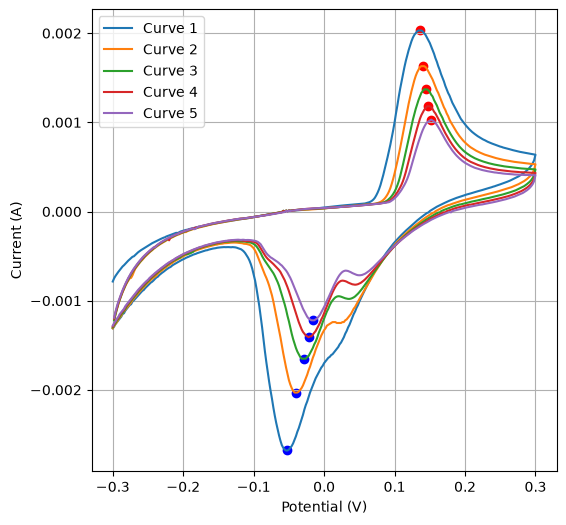

In [6]:
cv = CVAnalysis("graphene_oxide.csv")

# Analysis
peak_df = cv.calculate_peak_parameters()
charge_df = cv.calculate_charge()
cap_df = cv.calculate_capacitance([0.2, 0.4, 0.6, 0.8, 1.0])

# Display results
print(peak_df)
print(charge_df)
print(cap_df)

# Plot
cv.plot_cv_with_peaks()